Importación

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Carga de la tabla de barrios

In [3]:
zones = pd.read_csv(
    "../data/processed/zones_master.csv",
    dtype={
        "zone_key": "string",
        "neighborhood_code": "string",
        "district_code": "string",
    }
)

zones_geo = gpd.read_file(
    "../data/processed/zones_master.geojson"
)

print("Barrios:", len(zones))
print("Distritos:", zones["district_code"].nunique())

display(zones.head(10))

Barrios: 131
Distritos: 21


,zone_key,neighborhood_code,neighborhood_name,district_code,district_name,latitude,longitude,area_km2
0,MAD-011,011,Palacio,01,Centro,40.414971,-3.715596,1.469906
1,MAD-012,012,Embajadores,01,Centro,40.409558,-3.701534,1.033724
2,MAD-013,013,Cortes,01,Centro,40.414445,-3.698547,0.591874
3,MAD-014,014,Justicia,01,Centro,40.423895,-3.695812,0.739413
4,MAD-015,015,Universidad,01,Centro,40.425365,-3.706674,0.948026
5,MAD-016,016,Sol,01,Centro,40.416927,-3.704453,0.445301
6,MAD-021,021,Imperial,02,Arganzuela,40.406927,-3.717432,0.967679
7,MAD-022,022,Acacias,02,Arganzuela,40.400960,-3.706855,1.073437
8,MAD-023,023,Chopera,02,Arganzuela,40.394795,-3.699528,0.567787
9,MAD-024,024,Legazpi,02,Arganzuela,40.388089,-3.688611,1.414471


**NOTA**: Cada barrio tieene una clave propia que se llama *zone_key*

#### Comprobar la estructura

In [4]:
print("Dimensiones del CSV:", zones.shape)
print("Dimensiones del GeoJSON:", zones_geo.shape)

print("\nColumnas del CSV:")
print(zones.columns.tolist())

print("\nSistema de coordenadas del GeoJSON:")
print(zones_geo.crs)

Dimensiones del CSV: (131, 8)
Dimensiones del GeoJSON: (131, 9)

Columnas del CSV:
['zone_key', 'neighborhood_code', 'neighborhood_name', 'district_code', 'district_name', 'latitude', 'longitude', 'area_km2']

Sistema de coordenadas del GeoJSON:
EPSG:4326


**NOTA:** La diferencia de una columna es normal porque el GeoJSON añade la forma geográfica del barrio.

**NOTA:** EPSG:4326 indica el sistema usado para guardar las coordenadas. Aqui esta usando el formato habitual de latitud y longitud

### Comprobar valores ausentes y duplicados

In [5]:
validacion_basica = pd.DataFrame({
    "valores_nulos": zones.isna().sum(),
    "porcentaje_nulos": (zones.isna().mean() * 100).round(2),
    "valores_unicos": zones.nunique()
})

display(validacion_basica)

print("Zone keys duplicadas:", zones["zone_key"].duplicated().sum())
print(
    "Códigos de barrio duplicados:",
    zones["neighborhood_code"].duplicated().sum()
)

,valores_nulos,porcentaje_nulos,valores_unicos
zone_key,0,0.0,131
neighborhood_code,0,0.0,131
neighborhood_name,0,0.0,131
district_code,0,0.0,21
district_name,0,0.0,21
latitude,0,0.0,131
longitude,0,0.0,131
area_km2,0,0.0,131


Zone keys duplicadas: 0
Códigos de barrio duplicados: 0


### Comprobar las formas de los barrios

In [6]:
print("Geometrías ausentes:", zones_geo.geometry.isna().sum()) #comprueba si hay algun barrio que no tenga asociada ninguna forma
print("Geometrías vacías:", zones_geo.geometry.is_empty.sum()) #Comprueba si existe la geometría, pero está vacía
print("Geometrías inválidas:", (~zones_geo.geometry.is_valid).sum()) # Comprueba si alguna forma está mal construida y puede provocar errores al trabajar con mapas.

Geometrías ausentes: 0
Geometrías vacías: 0
Geometrías inválidas: 0


### Resumen por distritos

In [7]:
resumen_distritos = (
    zones.groupby(
        ["district_code", "district_name"],
        as_index=False
    )
    .agg(
        numero_barrios=("neighborhood_code", "nunique"),
        superficie_total_km2=("area_km2", "sum")
    )
    .sort_values("district_code")
)

resumen_distritos["superficie_total_km2"] = (
    resumen_distritos["superficie_total_km2"].round(3)
)

display(resumen_distritos)

print(
    "Total de barrios:",
    resumen_distritos["numero_barrios"].sum()
)

,district_code,district_name,numero_barrios,superficie_total_km2
0,01,Centro,6,5.228
1,02,Arganzuela,7,6.462
2,03,Retiro,6,5.466
3,04,Salamanca,6,5.392
4,05,Chamartín,6,9.175
5,06,Tetuán,6,5.375
6,07,Chamberí,6,4.679
7,08,Fuencarral - El Pardo,8,237.838
8,09,Moncloa - Aravaca,7,46.587
9,10,Latina,7,25.410


Total de barrios: 131


### **CONCLUSIONES**:

- *Ciudad Lineal* es el distrito con mas barrios; No significa que sea el distrito mas grande, sino que esta dividido en mas barrios

- *Villa de Vallecas* es el distrito con menos barrios (solo3) pero su superfcia es relativamente grande

- *Fuencarral- El Pardo* es el distrio con mayor superficie (237,838 km²)

- *Chamberí* es el distrito con menor superficie (4,679 km²)

- La *superficie total* es de aproximadamente 604 km²

### Crear el mapa

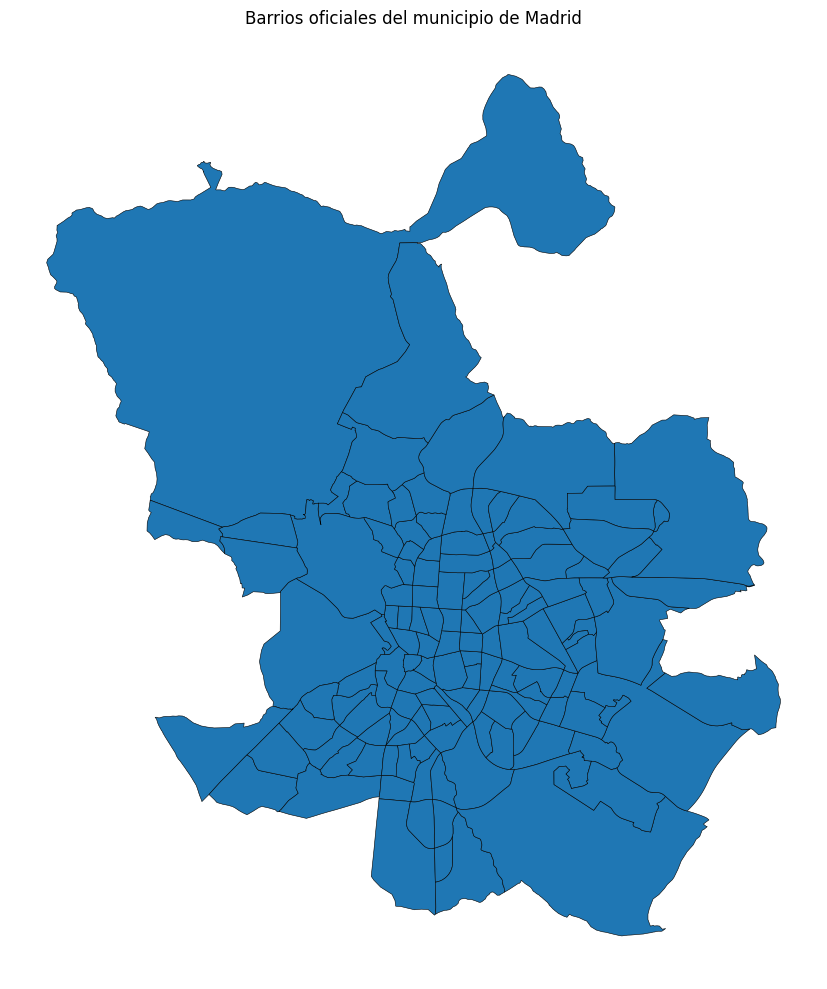

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

zones_geo.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Barrios oficiales del municipio de Madrid")
ax.set_axis_off()

plt.tight_layout()
plt.show()

**Cada distrito de un color**

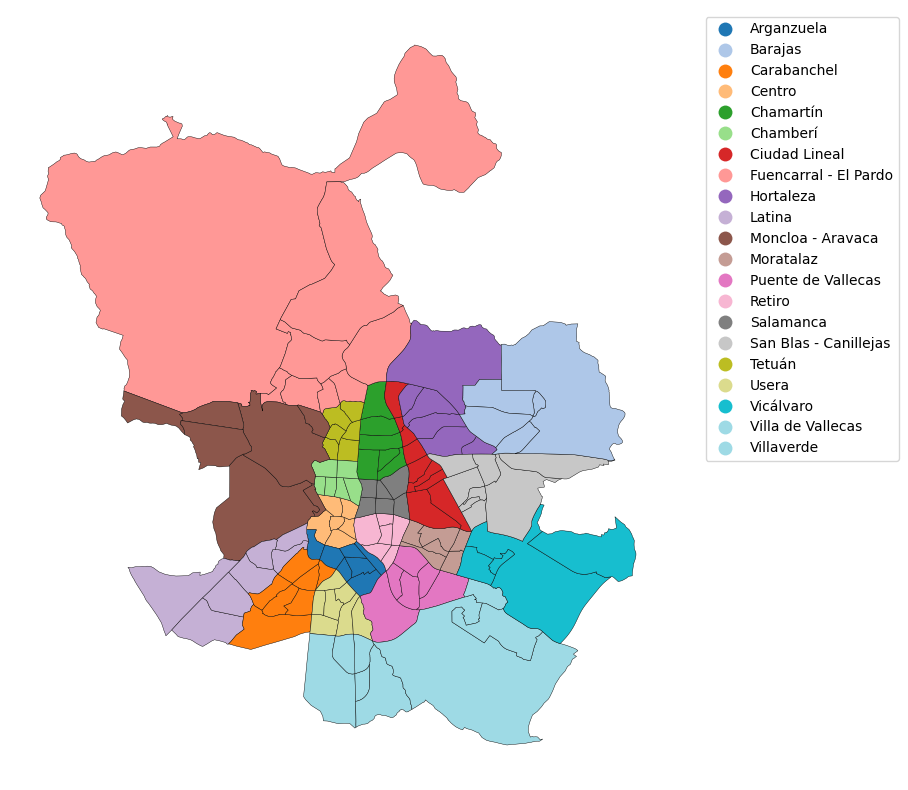

In [10]:
zones_geo.plot(column="district_name", categorical=True, cmap="tab20", edgecolor="black", linewidth=0.3, figsize=(12, 10), legend=True, legend_kwds={"bbox_to_anchor": (1.05, 1), "loc": "upper left"}).set_axis_off()

**Cada barrio de un color**

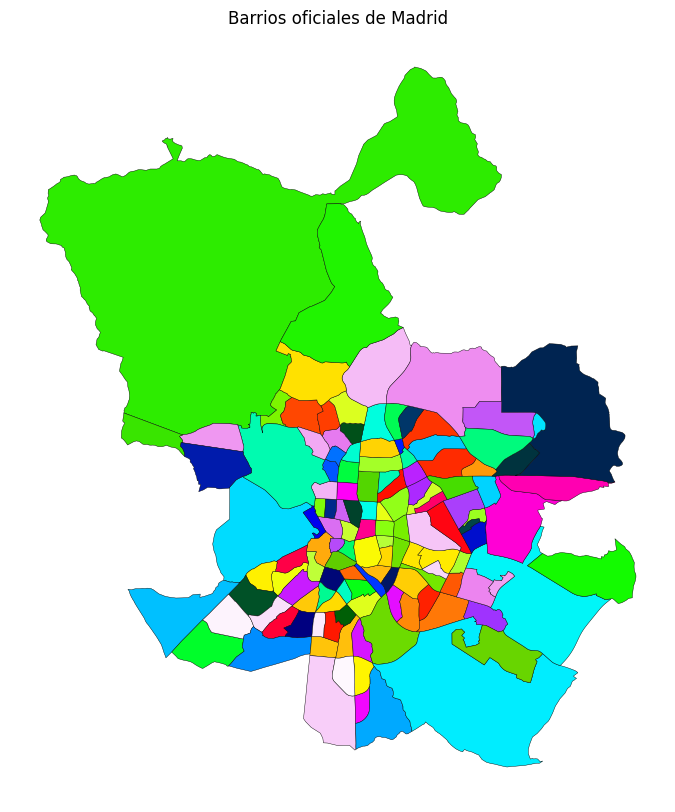

In [12]:
ax = zones_geo.plot(column="neighborhood_name", cmap="gist_ncar", edgecolor="black", linewidth=0.3, figsize=(10, 10), legend=False)
ax.set_title("Barrios oficiales de Madrid")
ax.set_axis_off()
plt.show()

### Validación final automática

In [8]:
assert len(zones) == 131, "No aparecen los 131 barrios"
assert zones["district_code"].nunique() == 21, "No aparecen los 21 distritos"
assert zones["zone_key"].duplicated().sum() == 0, "Hay zone_key duplicadas"
assert zones["neighborhood_code"].duplicated().sum() == 0, (
    "Hay códigos de barrio duplicados"
)
assert zones[
    [
        "zone_key",
        "neighborhood_code",
        "neighborhood_name",
        "district_code",
        "district_name",
        "latitude",
        "longitude",
        "area_km2",
    ]
].isna().sum().sum() == 0, "Hay valores esenciales ausentes"

assert zones_geo.geometry.isna().sum() == 0, "Hay geometrías ausentes"
assert zones_geo.geometry.is_empty.sum() == 0, "Hay geometrías vacías"
assert (~zones_geo.geometry.is_valid).sum() == 0, "Hay geometrías inválidas"

print(
    "VALIDACIÓN COMPLETADA: "
    "la tabla territorial contiene 131 barrios, "
    "21 distritos y no presenta errores básicos."
)

VALIDACIÓN COMPLETADA: la tabla territorial contiene 131 barrios, 21 distritos y no presenta errores básicos.
